In [1]:
import pyarrow.feather as feather

tbl = feather.read_table("cosmos_subset.feather", memory_map=True)
df = tbl.to_pandas(ignore_metadata=True)

In [2]:
df

,ID,ALPHA_J2000,DELTA_J2000,X_IMAGE,Y_IMAGE,ERRX2_IMAGE,ERRY2_IMAGE,ERRXY_IMAGE,FLUX_RADIUS,KRON_RADIUS,...,ez_ssfr_p160,ez_ssfr_p500,ez_ssfr_p840,ez_ssfr_p975,ez_Av_p025,ez_Av_p160,ez_Av_p500,ez_Av_p840,ez_Av_p975,__index_level_0__
0,202254,149.454499,1.604373,38594.570312,7524.651367,0.022555,0.017240,1.765368e-03,4.895420,6.615814,...,-8.756807,-7.976652,-7.976652,-7.976652,2.345828,2.419842,2.519183,2.579969,2.637177,202253
1,202263,149.465502,1.604387,38330.550781,7524.901367,0.006816,0.007299,6.177048e-05,2.050833,4.597410,...,-9.348090,-8.957371,-8.540674,-8.380679,0.109046,0.259459,0.482678,0.626702,0.820106,202262
2,202377,149.474741,1.604474,38108.859375,7526.908203,0.004499,0.004582,3.047340e-05,3.324043,4.170846,...,-9.151484,-8.893667,-8.412649,-8.205940,0.042471,0.042471,0.152718,0.527141,0.715415,202376
3,202399,149.668091,1.604602,33469.605469,7528.762695,0.019946,0.019066,3.598821e-03,3.452706,0.000000,...,-10.407327,-10.166462,-9.665212,-9.466089,0.042471,0.243749,1.151127,1.680741,2.199393,202398
4,202451,149.652446,1.604687,33844.976562,7530.876953,0.021615,0.019546,-1.385243e-03,2.543927,6.058273,...,-9.149781,-9.047778,-8.916500,-8.809074,0.027772,0.027772,0.027772,0.027772,0.027772,202450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408963,1465281,150.039827,2.813473,24549.265625,36541.621094,0.000008,0.000010,-3.611084e-08,5.347314,3.500000,...,-10.370341,-10.186152,-9.871971,-9.675848,0.575378,0.718779,0.858989,0.958472,1.007304,1465280
408964,1465347,150.078571,2.812721,23620.460938,36523.515625,0.000011,0.000014,1.882926e-06,11.538898,3.500000,...,-10.779718,-10.173298,-9.851422,-9.743323,0.394117,0.474699,0.647097,0.895862,1.019284,1465346
408965,1466127,149.846286,2.808246,29188.964844,36416.847656,0.000837,0.001740,-3.708377e-04,28.499537,4.426568,...,-9.158416,-8.766261,-8.492642,-8.351445,1.933411,2.187165,2.379775,2.592673,2.751748,1466126
408966,1466180,149.456702,2.815315,38528.851562,36590.238281,0.000073,0.000051,3.829013e-06,7.630884,3.500000,...,-9.450609,-9.292094,-9.140302,-9.036506,0.255321,0.361942,0.504733,0.655359,0.828897,1466179


In [7]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
f=glob('eazy*')
wave1={}
norm_flux1={}
for idx, i in enumerate(f):
    wave, flux = np.loadtxt(i, unpack=True)
    flux *= wave**2. / 3e18
    norm=np.sqrt(np.sum(flux**2))
    norm_flux=flux/norm
    wave1[i]=wave
    norm_flux1[i]=norm_flux
    

In [8]:
wave_grid = np.linspace(800, 20000, 1000)
norm_flux_interp={}
for idx, i in enumerate(wave1.keys()):
    norm_flux_int = np.interp(wave_grid, wave1[i], norm_flux1[i])
    norm_flux_int /= np.trapz(norm_flux_int, wave_grid)
    norm_flux_interp[i]=norm_flux_int

In [9]:
flux_list = []
for name in norm_flux_interp.keys():
    flux_list.append(norm_flux_interp[name])

data_matrix = np.array(flux_list)

from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(data_matrix)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


# Redshifting PCA components

In [ ]:
filt_use=['CFHT_u', 'CFHT_ustar', 'UVISTA_Y',
       'UVISTA_J', 'UVISTA_H', 'UVISTA_Ks', 'UVISTA_NB118',
       'SC_IB427', 'SC_IB464', 'SC_IA484', 'SC_IB505',
       'SC_IA527', 'SC_IB574', 'SC_IA624', 'SC_IA679',
       'SC_IB709', 'SC_IA738', 'SC_IA767', 'SC_IB827',
       'SC_NB711', 'SC_NB816', 'IRAC_CH1', 'IRAC_CH2',
       'IRAC_CH3', 'IRAC_CH4']

In [14]:
import numpy as np
from sedpy.observate import load_filters, getSED

fil=['cfht_u','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y','subaru_suprimecam_B','subaru_suprimecam_V','sc_IB427','sc_IB464','subaru_suprimecam_ia484','sc_IB505','subaru_suprimecam_ia527','sc_IB574','subaru_suprimecam_ia624','subaru_suprimecam_ia679','sc_IB709','subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767','sc_IB827','sc_NB711','sc_NB816','sc_gp','subaru_suprimecam_ip','subaru_suprimecam_zp','sc_zpp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J','vista_vircam_Y','vista_vircam_Ks','nb118','galex_NUV','galex_FUV','irac_ch1','irac_ch2']

filters=load_filters(fil)

In [16]:
import numpy as np
from scipy.special import factorial, gamma as func_gamma, gammaincc as func_gammaincc

linewv = np.array([1215.67, 1025.72, 972.537, 949.743, 937.803, 930.748, 926.226,
                    923.150, 920.963, 919.352, 918.129, 917.181, 916.429, 915.824, 915.329, 914.919, 914.576, 914.286, 914.039, 913.826, 913.641, 913.480, 913.339, 913.215, 913.104, 913.006, 912.918, 912.839, 912.768, 912.703, 912.645, 912.592, 912.543, 912.499, 912.458, 912.420, 912.385, 912.353, 912.324])
Rn = np.array([1.00000000e+00, 2.77633136e-01, 1.32485207e-01,
                    7.80473373e-02, 5.15207101e-02, 3.65562130e-02, 
                    2.72721893e-02, 2.11183432e-02, 1.68224852e-02, 
                    1.37159763e-02, 1.13786982e-02, 9.59763314e-03, 
                    8.19526627e-03, 7.07692308e-03, 6.17159763e-03, 
                    5.42840237e-03, 4.80946746e-03, 4.29053254e-03, 
                    3.84911243e-03, 3.47218935e-03, 3.14733728e-03, 
                    2.86568047e-03, 2.61952663e-03, 2.40414201e-03, 
                    2.21183432e-03, 2.04378698e-03, 1.89289941e-03, 
                    1.75798817e-03, 1.63668639e-03, 1.52781065e-03, 
                    1.42899408e-03, 1.33905325e-03, 1.25798817e-03, 
                    1.18343195e-03, 1.11538462e-03, 1.05266272e-03, 
                    9.95266272e-04, 9.42603550e-04, 8.93491124e-04])[:,None]

def tau_eff(z):
    z_1= 1.2593846589041013
    a_1= 1.405759341921824
    A1= 0.01549433546364817
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565

    return np.piecewise(z,[z<z_1, z>=z_1], [lambda x:A1*((1.+x))**a_1, lambda z:A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))])

def tau_eff_highz(z):
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565
    return A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))

def tau_lc_igm(zs, l_obs):
    lratio = l_obs/911.8
    tau_igm = 0.805*lratio**3. * (1/lratio - 1/(1+zs))
    return tau_igm

def tau_lc_lls(zs, l_obs, n0=0.15, beta=1.28, gamma=1.94, nterms = 10):
    lratio = l_obs/911.8 #ratio of observed wavelength to lyman limit, also z_LLS
    zs_p1 = 1+zs
    e_neg1 = 0.36787944117144233  #1/e
    if beta==1.28 and gamma==1.94:
        beta_m1 = 0.28
        gamma_p1 = 2.94
        gam_fn = 0.31340445237536
    else:
        gamma_p1 = gamma + 1
        beta_m1 = beta - 1
        gam_fn = func_gamma(2-beta,1)*func_gammaincc(2-beta,1)
        
    sum1 = _first_lls_sum(beta_m1,nterms)
    sum2 = _second_lls_sum(zs_p1, lratio, gamma_p1=gamma_p1, beta_m1=beta_m1, nterms=nterms)
    tau_lls = n0/(4+gamma-3*beta) * (gam_fn - e_neg1 - sum1) * ( zs_p1**(-3*beta_m1+gamma_p1) * lratio**(3*beta_m1) - np.power(lratio,gamma_p1)) - n0*sum2
    return tau_lls

def _first_lls_sum(beta_m1=0.28, nterms=10):
    #if default beta, nterms return precomputed
    if beta_m1 == 0.28 and nterms==10:
        return -1.3219480209375662
    else:
        # sums from n=0
        n = np.arange(0,nterms)
        return np.sum( (beta_m1) / (n - beta_m1) * (-1)**n / factorial(n) )

def _second_lls_sum(zs_p1, lratio, gamma_p1=2.94, beta_m1=0.28, nterms=10):
    # sums from n=1
    n = np.arange(1,1+nterms)[:,None] 
    if beta_m1 ==0.28 and gamma_p1 == 2.94 and nterms==10:
        gamma_3n_p1 = np.array([ 0.06,  3.06,  6.06,  9.06, 12.06, 15.06, 18.06, 21.06, 24.06,27.06])[:,None]
        term1 = np.array([-6.48148148e+00,  2.65997872e-02, -2.83116547e-03,
         3.46159020e-04, -4.09909024e-05,  4.51444675e-06,
        -4.57762778e-07,  4.27131736e-08, -3.67775581e-09,
         2.93360030e-10])[:,None]
    else:
        gamma_3n_p1 = 3*n - gamma_p1
        term1 = beta_m1 * (-1)**n / ( (gamma_3n_p1) * (n-beta_m1) * factorial(n) )
    term2 = zs_p1**(-gamma_3n_p1) * np.power(lratio, 3*n) - np.power(lratio,gamma_p1)
    return np.sum(term1*term2,axis=0)

def calc_transmission(z_s,l_obs,model='full', nlines = 30, z_lls=None):
    if z_lls is not None:
        if z_lls>z_s:
            raise ValueError('z_lls must be less than or equal to z_s or None')
    if nlines>39:
        raise ValueError('Maximum value for nlines is 39.')
    if model=='full':
        tau_lya = tau_eff
    elif model=='highz':
        tau_lya = tau_eff_highz
    elif model=='optimise':
        zbreak = 1.26
        if np.any(l_obs<zbreak):
            tau_lya = tau_eff
        else:
            tau_lya = tau_eff_highz
    zlook = np.outer(1./linewv[0:nlines],l_obs)-1
    tau_laf_i = np.zeros_like(zlook)
    mask_lya = zlook<z_s
    tau_laf_i[mask_lya] = tau_lya(zlook[mask_lya])
    tau_laf_i *= Rn[0:nlines]
    tau_lys = np.sum(tau_laf_i,axis=0)

    mask_lc = l_obs<911.8*(1.+z_s)
    tau_lc = np.zeros_like(l_obs)
    tau_lc[mask_lc] = tau_lc_igm(z_s,l_obs[mask_lc])

    tau_lls = np.zeros_like(l_obs)
    if z_lls is None:
        tau_lls[mask_lc] += tau_lc_lls(z_s,l_obs[mask_lc])
    else:
        lls_mask = l_obs<(911.8*(1+z_lls))
        tau_lls[lls_mask] = np.inf
    return np.exp(-(tau_lys+tau_lc+tau_lls))


In [17]:
z_grid=np.linspace(0,8,501)
z_grid=z_grid[1:]

In [18]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

In [37]:
f_z = {}
wave_z = {}
H = np.asarray(H)
wave_grid = np.asarray(wave_grid)

for z in z_grid:
    lam_obs=wave_grid * (1 + z)
    wave_z[z] = lam_obs
    dL = cosmo.luminosity_distance(z).value * 1e6  
    denom = (1 + z) * 4 * np.pi * dL**2
    #rest_waves = wave_grid / (1 + z)
    H_interp = np.array([np.interp(wave_grid, wave_grid, H_j)* 3631 * 1e6 for H_j in H])
    f = H_interp / denom
    t=calc_transmission(z, lam_obs)
    f_z[z]=f*t

In [38]:
pca_f={}
for i in z_grid:
    f=getSED(wave_z[i],f_z[i],filters,linear_flux=True)* 3631 * 1e6
    pca_f[i]=f
    

In [39]:
pca_f[0]=getSED(wave_grid,H,filters,linear_flux=True)* 3631 * 1e6

In [40]:
last_key = list(pca_f.keys())[-1]
last_value = pca_f[last_key]

# 2. Remove the last key-value pair
del pca_f[last_key]

# 3. Create a new dictionary with the last element as first
new_dict = {last_key: last_value}
new_dict.update(pca_f)


In [41]:
pca_f=new_dict

In [42]:
z_grid1=np.insert(z_grid,0,0)

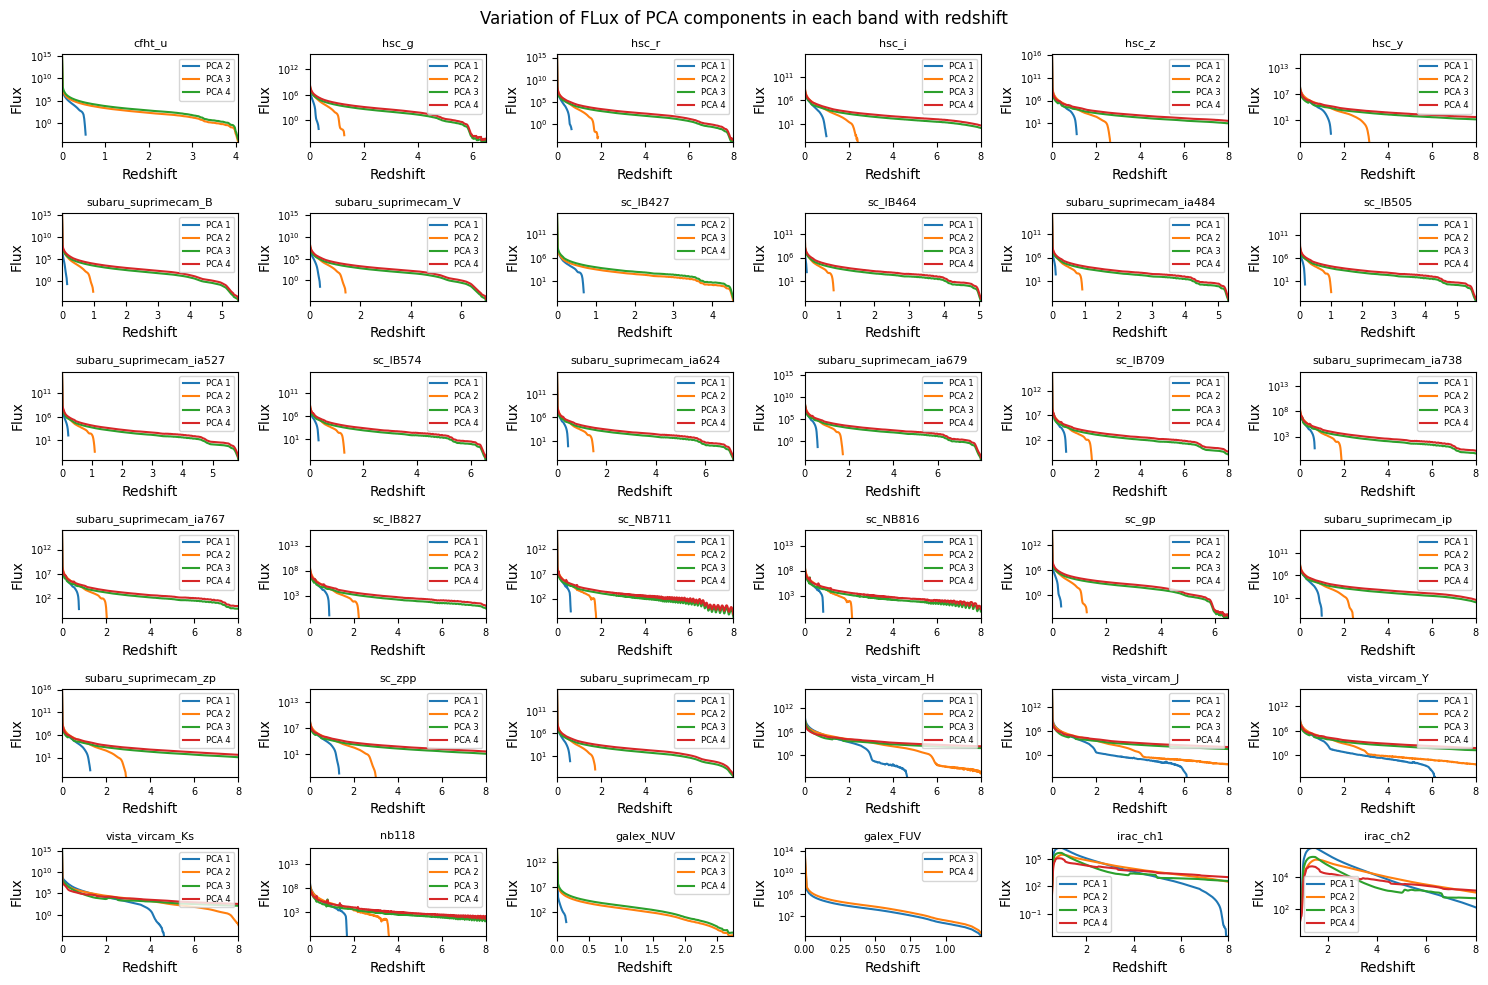

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Sort redshifts (keys)

# Convert f_z into a stacked array of shape (n_z, 4, 23)
f_alligm = np.array([pca_f[z] for z in z_grid1])  # shape: (n_z, 4, 23)
f_alligm = np.nan_to_num(f_alligm, nan=0.0)

n_pca, n_filters = f_alligm.shape[1], f_alligm.shape[2]

fig, axes = plt.subplots(6, 6, figsize=(15, 10), sharex=False, sharey=False)
axes = axes.flatten()

for filt_idx in range(n_filters):
    ax = axes[filt_idx]
    fluxes = f_alligm[:, :, filt_idx]  # shape (n_z, n_pca)
    
    for comp_idx in range(n_pca):
        flux = fluxes[:, comp_idx]
        
        # mask out regions where flux is zero or negligible
        mask = flux > 0
        if np.sum(mask) == 0:
            continue  # nothing to plot for this component
        
        # only keep valid parts of the curve
        z_valid = np.array(z_grid1)[mask]
        flux_valid = flux[mask]

        ax.plot(z_valid, flux_valid, label=f'PCA {comp_idx+1}')

    ax.set_title(f'{fil[filt_idx]}', fontsize=8)
    ax.set_xlabel('Redshift')
    ax.set_ylabel('Flux')
    ax.set_yscale('log')
    ax.tick_params(labelsize=7)
    ax.relim()
    ax.autoscale(enable=True, axis='both', tight=True)
    ax.legend(fontsize=6)

# Hide unused subplots
for ax in axes[n_filters:]:
    ax.axis('off')

# Legend only on the first plot

plt.suptitle('Variation of FLux of PCA components in each band with redshift')
plt.tight_layout()
plt.show()




In [28]:
np.save('zgrid.npy',z_grid1)

In [29]:
np.save('pcaflux_w_redshift_igm.npy',f_alligm)

In [44]:
np.save('pcaflux_w_redshift.npy',f_all)

# Mock Photometry

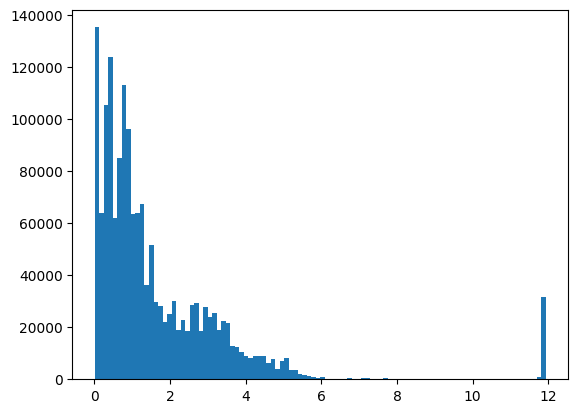

In [5]:
plt.hist(df['ez_z_phot'].tolist(),bins=100)
plt.show()

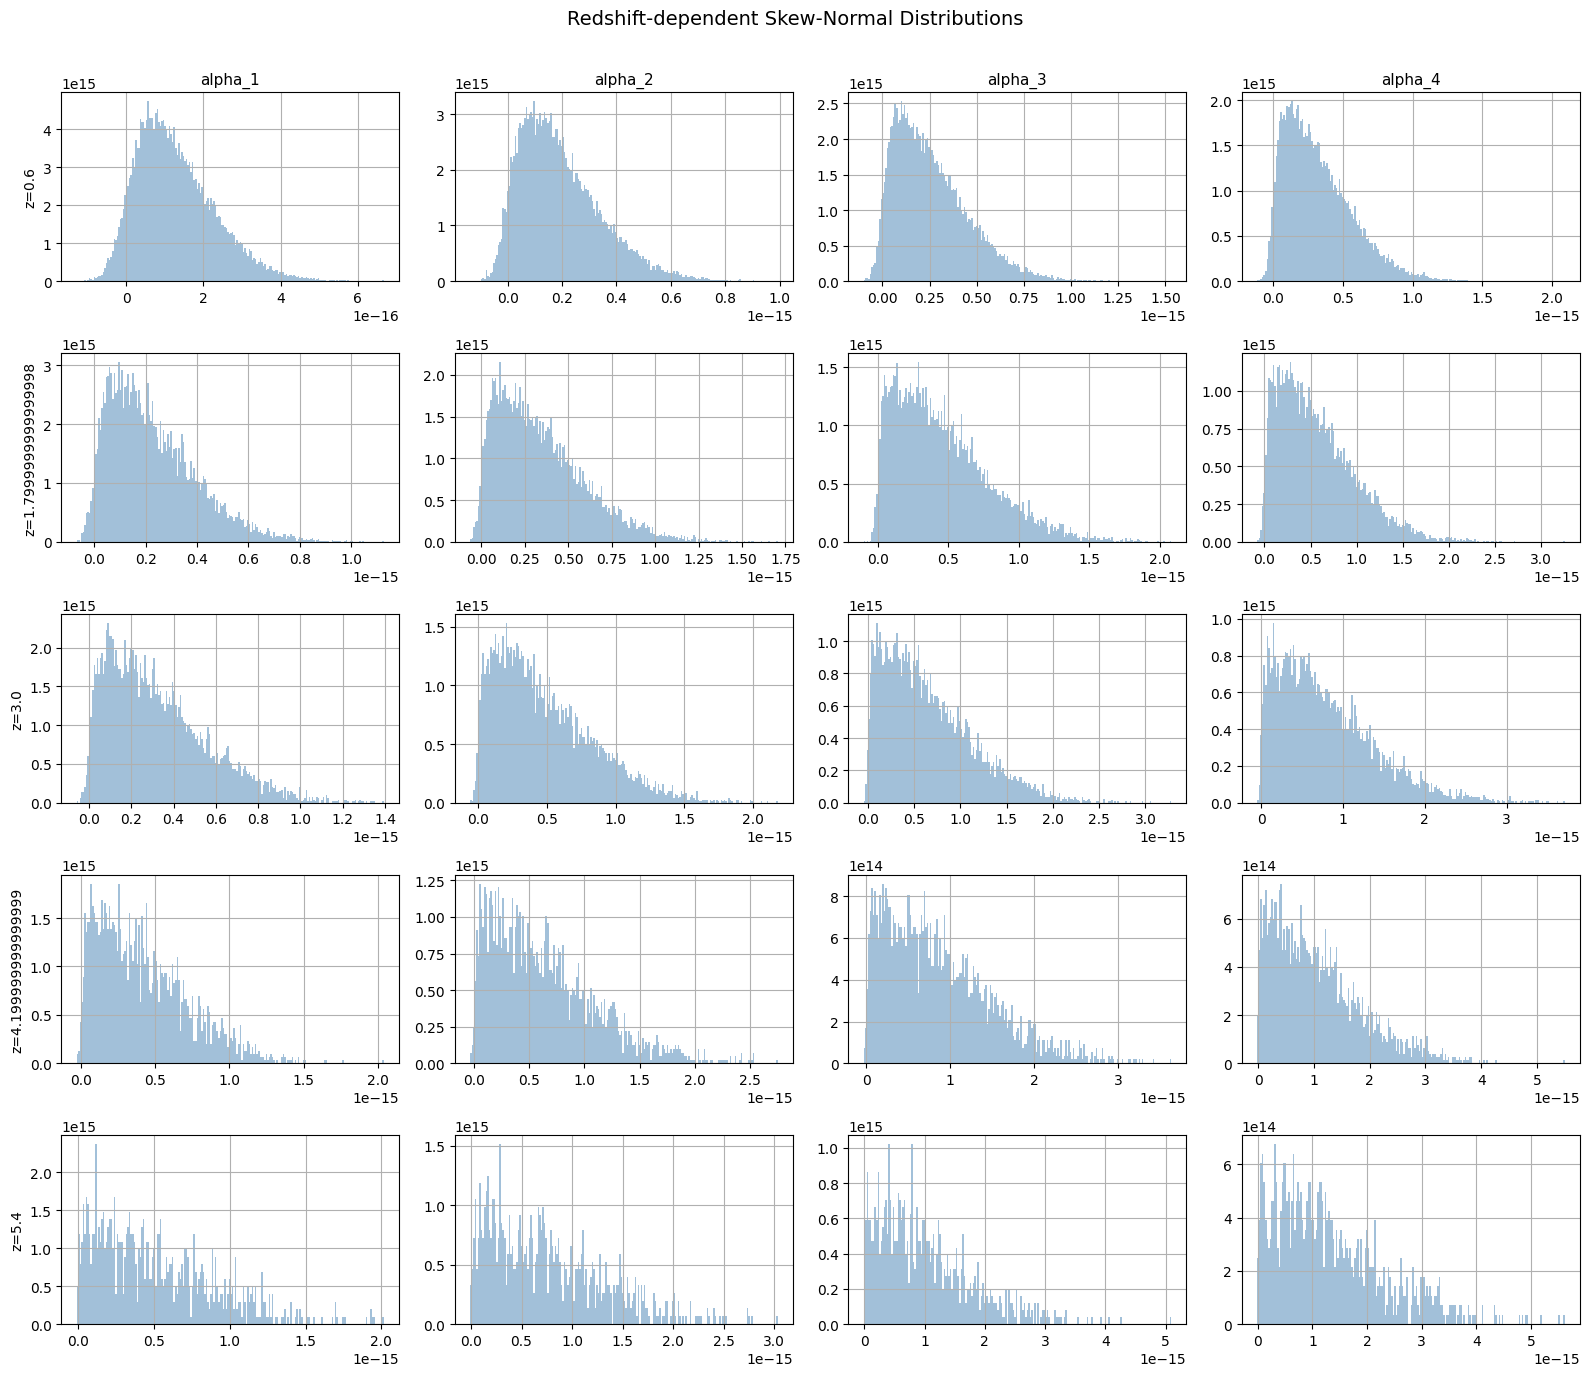

In [45]:
import numpy as np
from scipy.stats import skewnorm
import matplotlib.pyplot as plt

names = ['alpha_1', 'alpha_2', 'alpha_3', 'alpha_4']
x_min, x_max = -1e-15, 1e-15

# Create figure: 7 redshifts × 4 coefficients
# your empirical redshift histogram
counts, edges = np.histogram(df['ez_z_phot'].tolist(), bins=5, range=(0,6))
p_z = counts / counts.sum()
z_centers = 0.5*(edges[1:]+edges[:-1])
fig, axes = plt.subplots(len(z_centers), len(names), figsize=(16, 14))
s=[1,1.5,2,2.5]
rng = np.random.default_rng(42)

for i,(z, p) in enumerate(zip(z_centers, p_z)):
    n = int(50000 * p)       # proportional to observed density
    a = 2*(1+z)**2
    loc = 2e-18*(1+z)
    scale = 1e-16*(1+z)
    for j, (nm,sc) in enumerate(zip(names,s)):
        ax = axes[i, j]
        x = skewnorm.rvs(sc*a, loc=loc, scale=sc*scale, size=n, random_state=rng)
        x = x[(x >= x_min)]
        ax.hist(x, bins=200, density=True, alpha=0.5, color="steelblue")
        ax.grid()

        if i == 0:
            ax.set_title(f"{nm}", fontsize=11)
        if j == 0:
            ax.set_ylabel(f"z={z}", fontsize=10)

plt.suptitle("Redshift-dependent Skew-Normal Distributions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

        


In [206]:
import numpy as np
from scipy.stats import skewnorm

def generate_alpha_coeffs(z, n_gal, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    # Individual skewness scaling factors for each coefficient
    #s = np.array([1, 1.5, 2, 2.5])
    s = np.array([1,2,3,4])
   
    # Redshift-dependent shape, location, and scale
    a_base = 2* (1 + z)**2
    loc_base = 2e-18 * (1 + z)
    scale_base = 1e-16 * (1 + z)**2
    
    coeffs = np.empty((n_gal, len(s)))
    
    for j, sc in enumerate(s):
        a = sc * a_base
        loc = loc_base
        scale = sc * scale_base
        coeffs[:, j] = skewnorm.rvs(a, loc=loc, scale=scale, size=n_gal, random_state=rng)
    
    return coeffs
z=0
coeff_samples = generate_alpha_coeffs(z, n_gal=10000)

coeff_samples

array([[7.84698294e-17, 1.28309074e-16, 8.41676260e-17, 1.58480423e-16],
       [9.44303948e-17, 3.21237817e-16, 1.24555187e-16, 6.79450789e-16],
       [1.06964994e-16, 1.68708121e-16, 2.56415575e-17, 6.45009750e-16],
       ...,
       [1.03170468e-16, 1.04798090e-17, 1.82147335e-16, 4.73289362e-16],
       [1.92909142e-16, 4.00297663e-17, 1.05011470e-16, 4.42163589e-16],
       [6.63640192e-17, 3.26796545e-16, 5.49541814e-16, 3.67325789e-16]])

C:\Users\pranav\AppData\Local\Temp\ipykernel_45380\3365903510.py:11: RuntimeWarning: invalid value encountered in log10
  m=23.9-2.5*np.log10(flux[:,2])


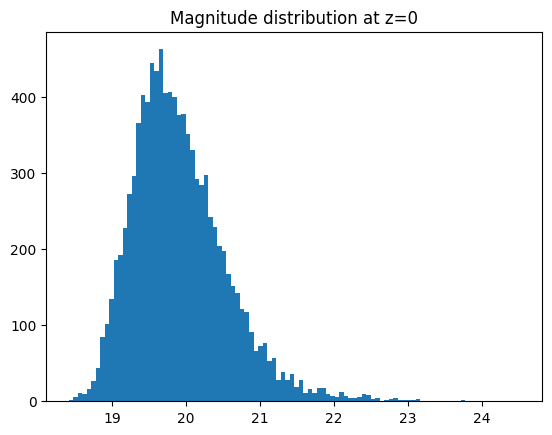

In [207]:
fil=['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y','subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484','subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679','subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767','subaru_suprimecam_ip','subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J','vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

import numpy as np
from sedpy.observate import load_filters, getSED

filters=load_filters(fil)
A = np.array(getSED(wave_grid, H, filters, linear_flux=True)*3631*1e6) 
flux=coeff_samples@A

m=23.9-2.5*np.log10(flux[:,2])
plt.hist(m,bins=100)
plt.title(f'Magnitude distribution at z={z}')
plt.show()

# Redshift dependant XD

In [13]:
import pandas as pd
df3 = pd.read_feather("cosmos_used_filter.feather")

In [14]:
df3

,X_IMAGE,Y_IMAGE,GALEX_NUV_FLUX,GALEX_FUV_FLUX,HSC_g_FLUX_APER2,HSC_r_FLUX_APER2,HSC_i_FLUX_APER2,HSC_z_FLUX_APER2,HSC_y_FLUX_APER2,SC_B_FLUX_APER2,...,SC_IA738_FLUX_APER2,SC_IA767_FLUX_APER2,SC_ip_FLUX_APER2,SC_zp_FLUX_APER2,SC_rp_FLUX_APER2,UVISTA_H_FLUX_APER2,UVISTA_J_FLUX_APER2,UVISTA_Y_FLUX_APER2,UVISTA_Ks_FLUX_APER2,ACS_F814W_FLUX
0,1304.953247,2579.132324,NaN,NaN,97.519783,229.977203,333.897583,491.040680,582.690369,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,818.016785,2725.062988,NaN,NaN,105.098213,118.250397,114.259003,179.894287,384.122742,0.037798,...,NaN,NaN,NaN,0.217983,0.060851,NaN,NaN,NaN,NaN,NaN
2,1324.814453,2583.007812,NaN,NaN,2.136770,4.961566,7.953316,9.829372,12.214380,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21610.509766,2415.219971,NaN,NaN,0.085408,0.071682,0.054122,0.022412,-0.000192,0.073336,...,NaN,NaN,NaN,-0.045704,0.126495,NaN,NaN,NaN,NaN,NaN
4,36540.632812,2414.936523,NaN,NaN,0.052692,0.043954,0.029368,0.124312,0.040235,0.110077,...,NaN,NaN,NaN,0.179530,0.106292,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720695,47059.863281,42735.585938,NaN,NaN,0.017862,0.041047,0.079659,0.124605,0.170460,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720696,47708.503906,42747.988281,NaN,NaN,NaN,NaN,0.000926,NaN,0.009624,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720697,47446.062500,42748.003906,NaN,NaN,NaN,NaN,0.000158,NaN,0.024071,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1720698,47640.492188,42747.992188,NaN,NaN,NaN,NaN,0.001315,NaN,0.018937,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
import pandas as pd

# Your two DataFrames:
# df_flux: the one with only fluxes (currently loaded)
# df_err: the one that already contains the corresponding error columns

def convert_to_err_colname(colname):
    parts = colname.replace('FLUX','FLUXERR')
    return parts
    

# Create mapping from flux column → error column
col_mapping = {}
for col in df3.columns:
    err_col = convert_to_err_colname(col)
    if err_col in df.columns:
        col_mapping[col] = err_col

# Copy over matching error columns
for flux_col, err_col in col_mapping.items():
    df3[err_col] = df[err_col]

print(f"Copied {len(col_mapping)} error columns from df_err to df_flux.")


Copied 25 error columns from df_err to df_flux.


In [16]:
df3=df3.drop('X_IMAGE',axis=1)

In [17]:
df3.columns

Index(['Y_IMAGE', 'GALEX_NUV_FLUX', 'GALEX_FUV_FLUX', 'HSC_g_FLUX_APER2',
       'HSC_r_FLUX_APER2', 'HSC_i_FLUX_APER2', 'HSC_z_FLUX_APER2',
       'HSC_y_FLUX_APER2', 'SC_B_FLUX_APER2', 'SC_V_FLUX_APER2',
       'SC_IA484_FLUX_APER2', 'SC_IA527_FLUX_APER2', 'SC_IA624_FLUX_APER2',
       'SC_IA679_FLUX_APER2', 'SC_IA738_FLUX_APER2', 'SC_IA767_FLUX_APER2',
       'SC_ip_FLUX_APER2', 'SC_zp_FLUX_APER2', 'SC_rp_FLUX_APER2',
       'UVISTA_H_FLUX_APER2', 'UVISTA_J_FLUX_APER2', 'UVISTA_Y_FLUX_APER2',
       'UVISTA_Ks_FLUX_APER2', 'ACS_F814W_FLUX', 'GALEX_NUV_FLUXERR',
       'GALEX_FUV_FLUXERR', 'HSC_g_FLUXERR_APER2', 'HSC_r_FLUXERR_APER2',
       'HSC_i_FLUXERR_APER2', 'HSC_z_FLUXERR_APER2', 'HSC_y_FLUXERR_APER2',
       'SC_B_FLUXERR_APER2', 'SC_V_FLUXERR_APER2', 'SC_IA484_FLUXERR_APER2',
       'SC_IA527_FLUXERR_APER2', 'SC_IA624_FLUXERR_APER2',
       'SC_IA679_FLUXERR_APER2', 'SC_IA738_FLUXERR_APER2',
       'SC_IA767_FLUXERR_APER2', 'SC_ip_FLUXERR_APER2', 'SC_zp_FLUXERR_APER2',
     

In [141]:
import numpy as np
from sedpy.observate import getSED, load_filters

# -----------------------------
# Setup
# -----------------------------
fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

filters = load_filters(fil)

# F_matrix: (M, Kc) where Kc = #PCA components
F_matrix = np.array([getSED(wave_grid, H_k, filters, linear_flux=True) * 3631 * 1e6
                     for H_k in H]).T  # (M, Kc)
FT = F_matrix.T  # (Kc, M)

# Photo-z mean and 1-sigma (Gaussian approx from 16–84th)
z = df['ez_z_phot'].to_numpy()
z_sigma = 0.5 * (df['ez_z840'] - df['ez_z160']).to_numpy()

# Mask bad/NaN redshifts
mask = np.isfinite(z) & np.isfinite(z_sigma) & (z_sigma > 0)
z = z[mask]
z_sigma = z_sigma[mask]

# Observed fluxes and errors (ensure these align to the same mask/order)
Y = np.nan_to_num(df3[df3.columns[:len(fil)]].to_numpy(float), nan=0.0)[mask]   # (N, M)
S = np.nan_to_num(df3[df3.columns[23:23+len(fil)]].to_numpy(float), nan=1e6)[mask]
R = S**2
N, M = Y.shape

# Latent dimensionalities
Kc = F_matrix.shape[1]  # coeffs
K  = Kc + 1             # coeffs + z  (last index is z)

# Prior initialization in the joint space [coeffs, z]
mean_prior = np.zeros(K)
cov_prior  = np.eye(K)
inv_cov_prior = np.linalg.inv(cov_prior)

# EM loop
num_iterations = 50
convergence_threshold = 1e-9
batch_size = 10000

print("--- XD (single-Gaussian) with noisy z ---")

for it in range(num_iterations):
    mu_old = mean_prior.copy()

    # Sufficient statistics in joint space
    sum_mean  = np.zeros(K)
    sum_cov   = np.zeros((K, K))
    sum_outer = np.zeros((K, K))

    for b in range(0, N, batch_size):
        i_end = min(b + batch_size, N)
        B = i_end - b

        Y_batch = Y[b:i_end]                   # (B, M)
        R_batch = R[b:i_end]                   # (B, M)
        z_batch = z[b:i_end]                   # (B,)
        zsig_b  = z_sigma[b:i_end]             # (B,)

        # Flux weights
        W   = 1.0 / R_batch                    # (B, M)
        W_Y = W * Y_batch                      # (B, M)

        # Redshift precision per object
        Wz = 1.0 / (zsig_b**2)                 # (B,)

        # ---- Build posterior precision A_i^{-1} per object in joint space ----
        # Start from prior precision
        A = np.broadcast_to(inv_cov_prior, (B, K, K)).copy()

        # Add flux term only to the coeff–coeff block: F^T W F
        # A_flux: (B, Kc, Kc)
        A_flux = np.einsum('km,bm,mj->bkj', FT, W, F_matrix)
        A[:, :Kc, :Kc] += A_flux

        # Add z_obs term only to the z–z entry
        A[:, Kc, Kc] += Wz

        # ---- Build RHS: Σ^{-1}μ + [F^T W Y; z_obs * Wz] ----
        rhs = np.tile((inv_cov_prior @ mean_prior)[None, :], (B, 1))  # (B, K)
        rhs[:, :Kc] += W_Y @ F_matrix                                  # coeff part (B, Kc)
        rhs[:,  Kc] += z_batch * Wz                                    # z part (B,)

        # Solve per object
        for i in range(B):
            Ai = A[i]
            rhsi = rhs[i]

            # Stabilize if needed
            # Ai += 1e-10 * np.eye(K)

            try:
                Ainv = np.linalg.inv(Ai)
            except np.linalg.LinAlgError:
                Ainv = np.linalg.pinv(Ai)

            x_post = Ainv @ rhsi   # posterior mean of [coeffs, z]
            sum_mean  += x_post
            sum_cov   += Ainv
            sum_outer += np.outer(x_post, x_post)

    # M-step: population mean/cov
    mean_prior = sum_mean / N
    cov_prior  = (sum_cov + sum_outer) / N - np.outer(mean_prior, mean_prior)

    # Recompute inverse (add a tiny jitter if needed)
    try:
        inv_cov_prior = np.linalg.inv(cov_prior)
    except np.linalg.LinAlgError:
        inv_cov_prior = np.linalg.pinv(cov_prior)

    delta_mu = np.linalg.norm(mean_prior - mu_old)
    print(f"Iter {it+1:02d} | Δμ = {delta_mu:.3e}")
    if delta_mu < convergence_threshold:
        break

print("\nFinal Prior Mean (coeffs..., z):\n", mean_prior)
print("\nFinal Prior Covariance (joint):\n", cov_prior)


--- XD (single-Gaussian) with noisy z ---


KeyboardInterrupt: 

In [146]:
(inv_cov_prior @ mean_prior).shape

(5,)

In [10]:
mean_prior= [ 3.23926777e-18 ,-1.68163283e-18,  1.18453195e-17 ,-3.17835860e-18,1.67621687e+00]
cov_prior=[[ 1.73417152e-32 ,-1.85997769e-32 , 2.01293673e-32, -6.26178023e-33,
   3.32216356e-17],
 [-1.85997769e-32 , 3.03084899e-32 ,-3.67523272e-32,  8.81601742e-33,
  -2.96931574e-17],
 [ 2.01293673e-32 ,-3.67523272e-32  ,1.28031670e-31 ,-7.80651275e-32,
   7.28858088e-17],
 [-6.26178023e-33  ,8.81601743e-33 ,-7.80651275e-32  ,6.32566018e-32,
  -3.71015919e-17],
 [ 3.32216356e-17 ,-2.96931574e-17  ,7.28858088e-17 ,-3.71015919e-17,
   3.64039914e+00]]

In [12]:
fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']

In [80]:
import numpy as np
from sedpy.observate import load_filters, getSED
filters = load_filters(fil)      # load all filters at once
A = np.array([
    getSED(wave_grid, H_k, filters, linear_flux=True) 
    for H_k in H
]).T   # shape → (n_bands, n_coeff)

A *= 3631 * 1e6

print(f"A.shape = {A.shape}")   # (n_bands, n_coeff)


A.shape = (23, 4)


C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


In [75]:
df1 = pd.read_feather("cosmos_used_filter.feather")


In [77]:
df1=df1.drop('X_IMAGE',axis=1)

In [78]:
z = df['ez_z_phot'].to_numpy()
z_sigma = 0.5 * (df['ez_z840'] - df['ez_z160']).to_numpy()

In [20]:
import numpy as np
mu = mean_prior # shape (n_coeff,) 
Sigma = cov_prior
# ----- Inputs -----
# A: (n_bands, n_coeff)
# mu_x: (n_coeff+1,)   # prior mean for [coeffs..., z]
# Sigma_x: (n_coeff+1, n_coeff+1)
# Y: (N_galaxies, n_bands)
# E: (N_galaxies, n_bands)
# z_obs: (N_galaxies,)
# z_sigma: (N_galaxies,)
Y = df1.to_numpy(float) 
Y = np.nan_to_num(Y, nan=0.0)  # (N_galaxies, n_bands)
E = df_err.to_numpy(float)  
E = np.nan_to_num(E, nan=1e6)  # (N_galaxies, n_bands)

# Compute 1/sigma^2 for each galaxy-band pair
W = 1.0 / (E**2)       

AT = A.T
Sigma_inv = np.linalg.inv(Sigma)

n_bands, n_coeff = A.shape
N = Y.shape[0]

coeffs_z = np.empty((N, n_coeff + 1))  # posterior mean [coeffs..., z]

for i in range(N):
    y = Y[i]
    e = E[i]
    z_i = z[i]
    sz_i = z_sigma[i]

    # Per-galaxy inverse noise weights
    W = 1.0 / (e**2)
    Rinv = np.diag(W)

    # ---- build block precision ----
    A_flux = AT @ (Rinv @ A)          # (n_coeff, n_coeff)
    rhs_flux = AT @ (Rinv @ y)        # (n_coeff,)

    # Joint precision and RHS
    A_joint = Sigma_inv.copy()
    A_joint[:n_coeff, :n_coeff] += A_flux
    A_joint[-1, -1] += 1.0 / (sz_i**2)

    rhs = Sigma_inv @ mu
    rhs[:n_coeff] += rhs_flux
    rhs[-1] += z_i / (sz_i**2)

    # ---- solve posterior mean ----
    try:
        C_post = np.linalg.inv(A_joint)
    except np.linalg.LinAlgError:
        C_post = np.linalg.pinv(A_joint)

    m_post = C_post @ rhs
    coeffs_z[i] = m_post

# coeffs_z[:, :-1] are the inferred PCA coefficients
# coeffs_z[:, -1]  are the inferred "true" redshifts


In [19]:
df_err = pd.read_feather("cosmos_used_error.feather")


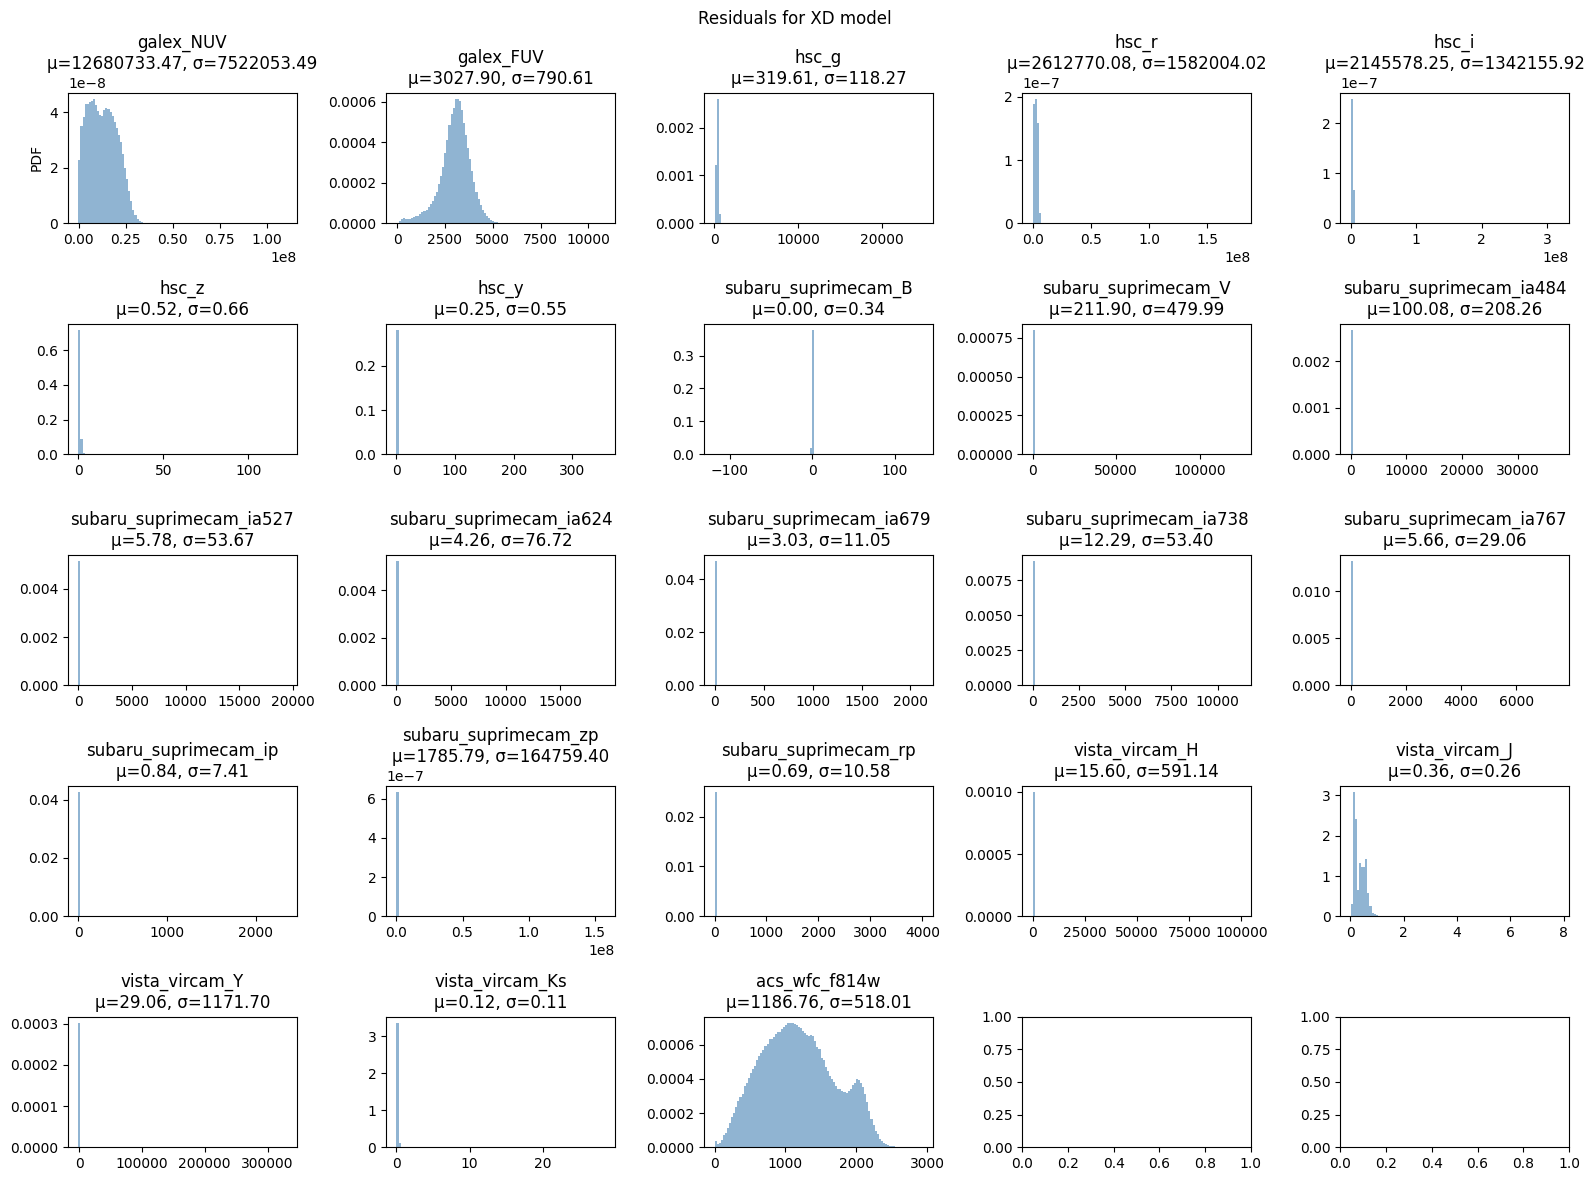

In [63]:
filt = load_filters(fil)
X = getSED(wave_grid, H, filt, linear_flux=True) * 3631 * 1e6 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes = axes.flatten()

n_gal, n_bands = df.shape
wave1=[np.median(filt[i].wavelength) for i in range(len(filt))]
# Precompute once
  # (n_bands, n_coeff)
z = df['ez_z_phot'].to_numpy()
dL = df['ez_dL'].to_numpy() * 3.08e32  # Mpc → Å (3.08e24 cm, but since flux ∝ 1/dL^2, scaling constant cancels later)

# Compute denominator vectorized: shape (N,)
denom = (1 + z)**2 * 4 * np.pi * dL  # luminosity distance scaling

# Compute model fluxes in one vectorized shot
# coeffs_z[:, :4]: (N, 4)
# A[:4, :]: (4, n_bands)
# wave_eff: (n_bands,)
# denom[:, None]: (N, 1)
model_flux_all = (coeffs_z[:, :4] @ ( * wave_eff)) / denom[:, None]

for i in range(min(n_bands, df_err.shape[1])):  #
    data  = df.iloc[:, i].to_numpy()
    error = df_err.iloc[:, i].to_numpy()

    mask = np.isfinite(data) & np.isfinite(error) & np.isfinite(model_flux_all[:,0])
    data, error = data[mask], error[mask]
    model = model_flux_all[mask,i]

    # Normalized residuals
    r = (data - model) / error
    #r_clip = r[np.abs(r) < 2]

    ax = axes[i]
    ax.hist(r, bins=100, density=True, alpha=0.6, color='steelblue')

    mu, sd = np.mean(r), np.std(r)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}")

axes[0].set_ylabel("PDF")
plt.suptitle('Residuals for XD model')
plt.tight_layout()
plt.show()


In [140]:
Y.shape

(1645765, 23)

# EM Algorithm

In [139]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters

# --------------------------------------------------------------------------
# This block is your data loading and setup code.
# You will need to replace the placeholder df and H generation with your actual data.
# --------------------------------------------------------------------------

# --- Setup Filters and PCA Basis ---
fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']
filters = load_filters(fil) # Assuming this is defined elsewhere

# For demonstration, creating placeholder data
N_galaxies = 10000
N_bands = len(fil)
Kc = 4 # Number of PCA components

# Create your PCA basis vectors `H`. Shape: (Kc, N_bands) -> (4, 23)
# >>> REPLACE this with your actual PCA components H and wave_grid. <<<

# F_matrix: This would be calculated using your getSED function
# For this demo, we'll create a placeholder projection matrix later.
F_matrix = np.array([getSED(wave_grid, H_k, filters, linear_flux=True) * 3631 * 1e6 for H_k in H]).T


# --------------------------------------------------------------------------
# Data Preparation
# --------------------------------------------------------------------------
print("--- Preparing Data ---")

# For the demo, create a simple projection matrix. You should use your F_matrix.
# This matrix projects from flux space to PCA coefficient space.
#projection_matrix = np.linalg.pinv(np.random.rand(N_bands, Kc)) # Placeholder
# In your code, this should be:
projection_matrix = np.linalg.pinv(F_matrix)

# Use photo-z mean as the predictor variable `z`
z = df['ez_z_phot'].to_numpy()
mask = np.isfinite(z) 
z = z[mask]

# Observed fluxes and errors (ensure these align to the same mask/order)
Y = np.nan_to_num(df3[df3.columns[:len(fil)]].to_numpy(float), nan=0.0)[mask]   # (N, M)
S = np.nan_to_num(df3[df3.columns[23:23+len(fil)]].to_numpy(float), nan=1e6)[mask]
R = S**2
N, M = Y.shape
assert M == len(fil)

# Pre-calculate observed PCA coefficients (W) and their covariances (S_w)
W_obs = np.zeros((N, Kc))
S_w = np.zeros((N, Kc, Kc))
for i in range(N):
    W_obs[i] = projection_matrix @ Y[i]
    S_flux_i = np.diag(R[i])
    S_w[i] = projection_matrix @ S_flux_i @ projection_matrix.T

# --------------------------------------------------------------------------
# Redshift-Dependent EM Algorithm
# --------------------------------------------------------------------------

# Initialization for the model parameters μ(z) = M0 + M1*z
M0 = np.mean(W_obs, axis=0)
M1 = np.zeros(Kc)
Sigma = np.cov(W_obs, rowvar=False)

# EM loop settings
num_iterations = 50
convergence_threshold = 1e-17
batch_size = 5000

print("\n--- EM for Redshift-Dependent Mean (p(coeffs|z)) ---")

for it in range(num_iterations):
    M0_old, M1_old = M0.copy(), M1.copy()

    # --- Initialize Sufficient Statistics for the M-step ---
    # For the linear regression part (M0, M1 update)
    sum_b = np.zeros(Kc)
    sum_zb = np.zeros(Kc)
    
    # For the Sigma update part
    sum_B = np.zeros((Kc, Kc))
    sum_b_outer = np.zeros((Kc, Kc))

    for b_idx in range(0, N, batch_size):
        i_end = min(b_idx + batch_size, N)
        B_size = i_end - b_idx

        # Get batches of pre-calculated data
        W_batch = W_obs[b_idx:i_end]
        Sw_batch = S_w[b_idx:i_end]
        z_batch = z[b_idx:i_end]

        # --- E-Step for the current batch ---
        # Calculate posterior mean (b_i) and covariance (B_i) for each object
        for i in range(B_size):
            wi = W_batch[i]
            Si = Sw_batch[i]
            zi = z_batch[i]

            mu_i = M0 + M1 * zi
            try:
                sig_i = np.linalg.inv(Sigma) 
                s_i = np.linalg.inv(Si)
    
                # Posterior mean b_i = E[v_i | w_i, z_i, θ]
                Bi = np.linalg.inv(sig_i + s_i) 
            except:
                sig_i = np.linalg.pinv(Sigma) 
                s_i = np.linalg.pinv(Si)
    
                # Posterior mean b_i = E[v_i | w_i, z_i, θ]
                Bi = np.linalg.pinv(sig_i + s_i)       # posterior covariance
            bi = Bi @ (sig_i @ mu_i + s_i @ wi)   

            # --- Accumulate sufficient statistics ---
            sum_b += bi
            sum_zb += zi * bi
            sum_B += Bi
            sum_b_outer += np.outer(bi, bi)

    # --- M-Step: Update parameters using accumulated statistics ---
    
    # 1. Update M0 and M1
    # Solve the 2x2 system for each of the Kc dimensions
    sum_z = np.sum(z)
    sum_z2 = np.sum(z**2)
    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    A_reg_inv = np.linalg.inv(A_reg)
    
    rhs = np.vstack([sum_b, sum_zb]) # Shape (2, Kc)
    M0, M1 = A_reg_inv @ rhs         # Shape (2, Kc)
    mu_new=M0
    # 2. Update Sigma
    # Sigma_new = (1/N) * Σ [ B_i + E[(v_i - μ_new_i)(v_i - μ_new_i)^T] ]
    # which expands to using the sufficient statistics.
    mu_b_outer = np.outer(M0, sum_b) + np.outer(M1, sum_zb)
    mu_mu_outer = N * np.outer(M0, M0) + sum_z * (np.outer(M0, M1) + np.outer(M1, M0)) + sum_z2 * np.outer(M1, M1)
    
    Sigma = (sum_B + sum_b_outer - mu_b_outer - mu_b_outer.T + mu_mu_outer) / N

    # --- Convergence Check ---
    delta_M = np.linalg.norm(M0 - M0_old) + np.linalg.norm(M1 - M1_old)
    print(f"Iter {it+1:02d} | ΔM = {delta_M:.3e}")
    if delta_M < convergence_threshold:
        print("Convergence threshold reached.")
        break

print("\n--- Fit Complete ---")
print("\nFinal M0 (mean at z=0):\n", M0)
print("\nFinal M1 (redshift evolution of mean):\n", M1)
print("\nFinal Sigma (intrinsic covariance of coeffs):\n", Sigma)

--- Preparing Data ---

--- EM for Redshift-Dependent Mean (p(coeffs|z)) ---


KeyboardInterrupt: 

In [67]:
M0=[ 7.92611020e-19,3.72214622e-17, -1.53056231e-16 , 5.62150603e-17]
M1=[-9.78495984e-19 ,-2.14220415e-17 , 1.06085033e-16, -3.69450946e-17]
Sigma=[[ 1.82300951e-31 , 2.79451546e-31 ,-2.64234156e-31 ,-6.14397061e-31],
 [ 2.79451538e-31 , 6.71692835e-31 ,-1.31342012e-30, -5.21204915e-31],
 [-2.64234120e-31 ,-1.31342007e-30 , 4.50272828e-30 ,-1.22190662e-30],
 [-6.14397083e-31 ,-5.21204980e-31 ,-1.22190645e-30  ,3.31344484e-30]]

In [93]:
import numpy as np

mu = np.add(M0,np.add(M1, M1)) # shape (n_coeff,) 
# ----- Inputs -----
# A: (n_bands, n_coeff)
# mu_x: (n_coeff+1,)   # prior mean for [coeffs..., z]
# Sigma_x: (n_coeff+1, n_coeff+1)
# Y: (N_galaxies, n_bands)
# E: (N_galaxies, n_bands)
# z_obs: (N_galaxies,)
# z_sigma: (N_galaxies,)
Y = df1.to_numpy(float) 
Y = np.nan_to_num(Y, nan=0.0)  # (N_galaxies, n_bands)
E = df_err.to_numpy(float)  
E = np.nan_to_num(E, nan=1e6)  # (N_galaxies, n_bands)

# Compute 1/sigma^2 for each galaxy-band pair
W = 1.0 / (E**2)       

AT = A.T
Sigma_inv = np.linalg.inv(Sigma)

n_bands, n_coeff = A.shape
N = Y.shape[0]

coeffs_z_2 = np.empty((N, n_coeff + 1))  # posterior mean [coeffs..., z]

for i in range(N):
    y = Y[i]
    e = E[i]
    z_i = z[i]
    sz_i = z_sigma[i]

    # Per-galaxy inverse noise weights
    W = 1.0 / (e**2)
    Rinv = np.diag(W)

    # ---- build block precision ----
    A_flux = AT @ (Rinv @ A)          # (n_coeff, n_coeff)
    rhs_flux = AT @ (Rinv @ y)        # (n_coeff,)

    # Joint precision and RHS
    A_joint = Sigma_inv.copy()
    A_joint[:n_coeff, :n_coeff] += A_flux
    A_joint[-1, -1] += 1.0 / (sz_i**2)

    rhs = Sigma_inv @ mu
    rhs[:n_coeff] += rhs_flux
    rhs[-1] += z_i / (sz_i**2)

    # ---- solve posterior mean ----
    try:
        C_post = np.linalg.inv(A_joint)
    except np.linalg.LinAlgError:
        C_post = np.linalg.pinv(A_joint)

    m_post = C_post @ rhs
    coeffs_z_2[i] = m_post

# coeffs_z[:, :-1] are the inferred PCA coefficients
# coeffs_z[:, -1]  are the inferred "true" redshifts


ValueError: could not broadcast input array from shape (4,) into shape (5,)

In [94]:
filt = load_filters(fil)
X = getSED(wave_grid, H, filt, linear_flux=True) * 3631 * 1e6 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes = axes.flatten()

n_gal, n_bands = df.shape
wave1=[np.median(filt[i].wavelength) for i in range(len(filt))]
# Precompute once
  # (n_bands, n_coeff)
z = df['ez_z_phot'].to_numpy()
dL = df['ez_dL'].to_numpy() * 3.08e32  # Mpc → Å (3.08e24 cm, but since flux ∝ 1/dL^2, scaling constant cancels later)

# Compute denominator vectorized: shape (N,)
denom = (1 + z)**2 * 4 * np.pi * dL  # luminosity distance scaling

# Compute model fluxes in one vectorized shot
# coeffs_z[:, :4]: (N, 4)
# A[:4, :]: (4, n_bands)
# wave_eff: (n_bands,)
# denom[:, None]: (N, 1)
model_flux_all = (coeffs_z[:, :4] @ (X * wave_eff)) / denom[:, None]

for i in range(min(n_bands, df_err.shape[1])):  #
    data  = df.iloc[:, i].to_numpy()
    error = df_err.iloc[:, i].to_numpy()

    mask = np.isfinite(data) & np.isfinite(error) & np.isfinite(model_flux_all[:,0])
    data, error = data[mask], error[mask]
    model = model_flux_all[mask,i]

    # Normalized residuals
    r = (data - model) / error
    #r_clip = r[np.abs(r) < 2]

    ax = axes[i]
    ax.hist(r, bins=100, density=True, alpha=0.6, color='steelblue')

    mu, sd = np.mean(r), np.std(r)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}")

axes[0].set_ylabel("PDF")
plt.suptitle('Residuals for XD model')
plt.tight_layout()
plt.show()


(4, 4)

# Final Algorithm

In [270]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters
from scipy.interpolate import RegularGridInterpolator
import time

# --------------------------------------------------------------------------
# Load and prepare data
# --------------------------------------------------------------------------
f_all = np.load('pcaflux_w_redshift.npy')   # shape: (Nz, Kc, Nbands)
           # must exist
f_interp_vec = RegularGridInterpolator((z_grid1,), f_all, bounds_error=False, fill_value=None)

fil = ['galex_NUV','galex_FUV','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y',
       'subaru_suprimecam_B','subaru_suprimecam_V','subaru_suprimecam_ia484',
       'subaru_suprimecam_ia527','subaru_suprimecam_ia624','subaru_suprimecam_ia679',
       'subaru_suprimecam_ia738','subaru_suprimecam_ia767','subaru_suprimecam_ip',
       'subaru_suprimecam_zp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J',
       'vista_vircam_Y','vista_vircam_Ks','acs_wfc_f814w']
filters = load_filters(fil)

N_bands = len(fil)
Kc = 4
K  = Kc + 1

# Example data loading — replace with your actual `df` and `df3`
# df: photo-z table, df3: flux table with errors
z = df['ez_z_phot'].to_numpy()
z_sigma = (0.5 * (df['ez_z840'] - df['ez_z160']).to_numpy())**2
mask = np.isfinite(z) & np.isfinite(z_sigma) & (z_sigma > 0)
z, z_sigma = z[mask], z_sigma[mask]

Y = np.nan_to_num(df3[df3.columns[:N_bands]].to_numpy(float), nan=0.0)[mask]
S = np.nan_to_num(df3[df3.columns[23:23+N_bands]].to_numpy(float), nan=1e6)[mask]
R = S**2
N, M = Y.shape
assert M == N_bands

# PCA basis matrix for projection
F_matrix = np.array([getSED(wave_grid, H_k, filters, linear_flux=True)*3631*1e6 for H_k in H]).T
projection_matrix = np.linalg.pinv(F_matrix)
W_obs = np.zeros((N, K))
W_obs[:, :Kc] = Y @ projection_matrix.T
W_obs[:, Kc]  = z

# --------------------------------------------------------------------------
# Initialize parameters
# --------------------------------------------------------------------------
M0 = np.mean(W_obs, axis=0)
M1 = np.zeros(K)
Sigma = np.cov(W_obs, rowvar=False)
Sigma_inv = np.linalg.inv(Sigma)

num_iterations = 50
convergence_threshold = 1e-25
batch_size = 5000

# --------------------------------------------------------------------------
# EM Algorithm (vectorized)
# --------------------------------------------------------------------------
print("\n--- EM for Redshift-Dependent Mean (vectorized) ---")
LL = []

for it in range(num_iterations):
    start = time.time()
    M0_old, M1_old = M0.copy(), M1.copy()

    # Initialize accumulators
    sum_b = np.zeros((K, 1))
    sum_zb = np.zeros((K, 1))
    sum_B = np.zeros((K, K))
    sum_b_outer = np.zeros((K, K))
    logL = 0.0

    # Process in batches
    for b_start in range(0, N, batch_size):
        b_end = min(b_start + batch_size, N)
        Yb, Rb, zb, zsigb = Y[b_start:b_end], R[b_start:b_end], z[b_start:b_end], z_sigma[b_start:b_end]
        B = b_end - b_start

        # Vectorized interpolation of redshifted SEDs
        Fz = f_interp_vec(zb)                  # shape: (B, Kc, M)
        Rinv = 1.0 / Rb
        zsigi = 1.0 / (zsigb**2)

        # Build Ai for each object
        Ai_core = np.einsum('bkm,bm,bjm->bkj', Fz, Rinv, Fz)  # (B,Kc,Kc)
        Ai_full = np.zeros((B, K, K))
        Ai_full[:, :Kc, :Kc] = Ai_core
        Ai_full[:, Kc, Kc] = zsigi
        Ai_full += Sigma_inv[None, :, :]
        try:
            Bi = np.linalg.inv(Ai_full)  # (B,K,K)
        except:
            Bi = np.linalg.pinv(Ai_full)

        rhs1 = np.zeros((B, K))
        rhs1[:, :Kc] = np.einsum('bkm,bm->bk', Fz, Rinv * Yb)
        rhs1[:, Kc]  = zb * zsigi

        mu_i = M0 + M1 * zb[:, None]
        bi = np.einsum('bij,bj->bi', Bi, (Sigma_inv @ mu_i.T).T + rhs1)

        # Accumulate sufficient statistics
        sum_b += np.sum(bi, axis=0, keepdims=True).T
        sum_zb += np.sum(zb[:, None] * bi, axis=0, keepdims=True).T
        sum_B += np.sum(Bi, axis=0)
        sum_b_outer += np.einsum('bi,bj->ij', bi, bi)

        # Vectorized log-likelihood
        Fz_T = np.transpose(Fz, (0, 2, 1))
        resid = Yb - np.einsum('bmk,bk->bm', Fz_T, mu_i[:, :Kc])
        Ci = np.einsum('bmk,kl,bln->bmn', Fz_T, Sigma[:Kc,:Kc], Fz) + np.array([np.diag(Rb[i]) for i in range(B)])
        Ci += np.eye(M)[None, :, :] * 1e-28
        logdet = np.linalg.slogdet(Ci)[1]
        resid_solved = np.linalg.solve(Ci, resid[..., None]).squeeze(-1)  # (B, M)
        quad = np.einsum('bm,bm->b', resid, resid_solved)
        logL += np.sum(-0.5 * (quad + logdet + M * np.log(2*np.pi)))

    # --- M-Step ---
    sum_z = np.sum(z)
    sum_z2 = np.sum(z**2)
    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    A_reg_inv = np.linalg.inv(A_reg)
    rhs2 = np.vstack([sum_b.T[0], sum_zb.T[0]])  # (2,K)
    M0, M1 = A_reg_inv @ rhs2

    mu_b_outer = np.outer(M0, sum_b) + np.outer(M1, sum_zb)
    mu_mu_outer = N * np.outer(M0, M0) + sum_z * (np.outer(M0, M1) + np.outer(M1, M0)) + sum_z2 * np.outer(M1, M1)
    Sigma = (sum_B + sum_b_outer - mu_b_outer - mu_b_outer.T + mu_mu_outer) / N
    Sigma_inv = np.linalg.inv(Sigma)

    # Convergence check
    delta_M = np.linalg.norm(M0[:4]-M0_old[:4]) + np.linalg.norm(M1[:4]-M1_old[:4])
    LL.append(logL)
    end = time.time()
    print(end-start)
    print(f"Iter {it+1:02d} | ΔM = {delta_M:.3e} | logL = {logL:.3e} | time = {(end-start):.1f}s")
    if delta_M < convergence_threshold:
        print("Converged.")
        break

print("\n--- Fit Complete ---")
print("Final M0 (mean at z=0):\n", M0)
print("\nFinal M1 (redshift evolution):\n", M1)
print("\nFinal Sigma (intrinsic covariance):\n", Sigma)



--- EM for Redshift-Dependent Mean (vectorized) ---
863.4830317497253
Iter 01 | ΔM = 3.477e-16 | logL = -5.506e+16 | time = 863.5s
912.3232734203339
Iter 02 | ΔM = 2.506e-16 | logL = -5.506e+16 | time = 912.3s
886.7768013477325
Iter 03 | ΔM = 3.130e-16 | logL = -5.506e+16 | time = 886.8s
902.5057492256165
Iter 04 | ΔM = 3.212e-16 | logL = -5.506e+16 | time = 902.5s
920.1383574008942
Iter 05 | ΔM = 3.210e-16 | logL = -5.506e+16 | time = 920.1s
903.1399502754211
Iter 06 | ΔM = 3.191e-16 | logL = -5.506e+16 | time = 903.1s
861.1570794582367
Iter 07 | ΔM = 3.168e-16 | logL = -5.506e+16 | time = 861.2s
888.6113905906677
Iter 08 | ΔM = 3.144e-16 | logL = -5.506e+16 | time = 888.6s
824.4936306476593
Iter 09 | ΔM = 3.120e-16 | logL = -5.506e+16 | time = 824.5s
817.9117164611816
Iter 10 | ΔM = 3.097e-16 | logL = -5.506e+16 | time = 817.9s
844.4534347057343
Iter 11 | ΔM = 3.073e-16 | logL = -5.506e+16 | time = 844.5s
904.4938273429871
Iter 12 | ΔM = 3.049e-16 | logL = -5.506e+16 | time = 904.5s

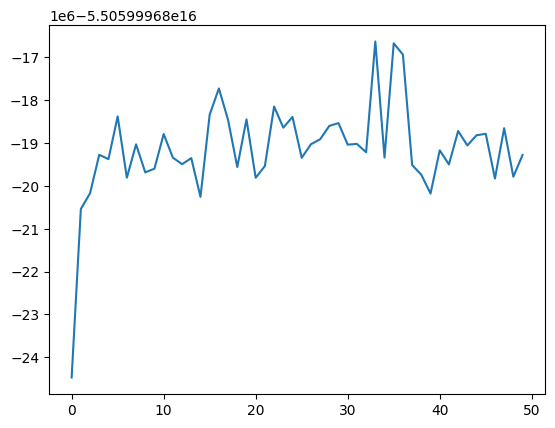

In [271]:
plt.plot(LL)